<a href="https://colab.research.google.com/github/AW-OMW/FLY-RANK-PROJECT/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AW-OMW/FLY-RANK-PROJECT/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

In [13]:
#freestyle: which pages suddenly boom overnight?
#Some pages suddenly show a strong growth trend in 30 days , which is due to change in user interest or other factors such as seo optimisation or fixes in page content.so to understand which pages have potential for next boom i would like to try and train a model for accurate prediction as possible.


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

In [14]:
#The decision of choosing which pages that can potentially boom next
#It can be acted upon by seo and users to find suitable content more faster and benefit from good quality data
#cost of wrong call can be either a page predicted to boom does not boom or opposite of it , either of which can result into change in user choices and seo model

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [15]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

In [16]:
import pandas as pd

# Load the raw dataset
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# View the first 5 rows
print(df.head())

# View column names
print(df.columns)

# Check data types
print(df.info())

             content_id          client_id  search_volume  competition  \
0  content_304f48230142  client_f369cb89fc           10.0         0.67   
1  content_a1fb4e703a9e  client_4e07408562           90.0         0.01   
2  content_9aa793d4d895  client_7f2253d7e2            0.0         0.00   
3  content_331d6c4de07b  client_19581e27de           10.0         0.00   
4  content_d99b7a2d90ca  client_3fdba35f04            0.0         0.00   

  competition_level   cpc     content_type    main_intent  word_count  \
0              HIGH  2.05  keyword article  transactional      3221.0   
1               LOW  0.05  keyword article  informational      2481.0   
2               LOW  0.00  keyword article  informational      3515.0   
3               LOW  0.00  keyword article     commercial         NaN   
4               LOW  0.00  keyword article  informational      2803.0   

   char_count  ... char_count_tier   ctr  avg_position  engagement_rate  \
0     20457.0  ...     15000-25000  0.76 

In [17]:
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Keep only rows where both impression columns are not null
df = df[
    df["impressions_last_30d"].notna() &
    df["impressions_prev_30d"].notna()
].copy()

# Calculate the difference
df["diff"] = df["impressions_last_30d"] - df["impressions_prev_30d"]

# Calculate percentage change
df["pct_change"] = np.where(
    df["impressions_prev_30d"] == 0,
    np.nan,
    df["diff"] / df["impressions_prev_30d"]
)

# Select only the required columns
result = df[
    [
        "client_id", # Changed from client_hash_id as per df.columns
        "content_id", # Changed from content_hash_id as per df.columns
        # "query_hash_id", # query_hash_id not found in df.columns, omitting
        "impressions_last_30d",
        "impressions_prev_30d",
        "diff",
        "pct_change"
    ]
]

# Sort by the absolute value of diff (largest changes first)
result = result.sort_values(
    by="diff",
    key=lambda x: x.abs(),
    ascending=False
)

# Display the top 5 rows
print(result.head(5))

# Optional: Save the results to a CSV file
result.head(5).to_csv("top_5_impression_changes.csv", index=False)

               client_id            content_id  impressions_last_30d  \
15405  client_6208ef0f77  content_a023517539fe                212015   
18870  client_4e07408562  content_db5989a78dd3                238796   
3331   client_6208ef0f77  content_4a6607efcb46                122303   
6653   client_4e07408562  content_5fe46e04994d                120791   
25507  client_19581e27de  content_e59e3357a212                101153   

       impressions_prev_30d    diff  pct_change  
15405                   757  211258  279.072655  
18870                 36393  202403    5.561592  
3331                   2213  120090   54.265703  
6653                 218786  -97995   -0.447903  
25507                 25591   75562    2.952679  


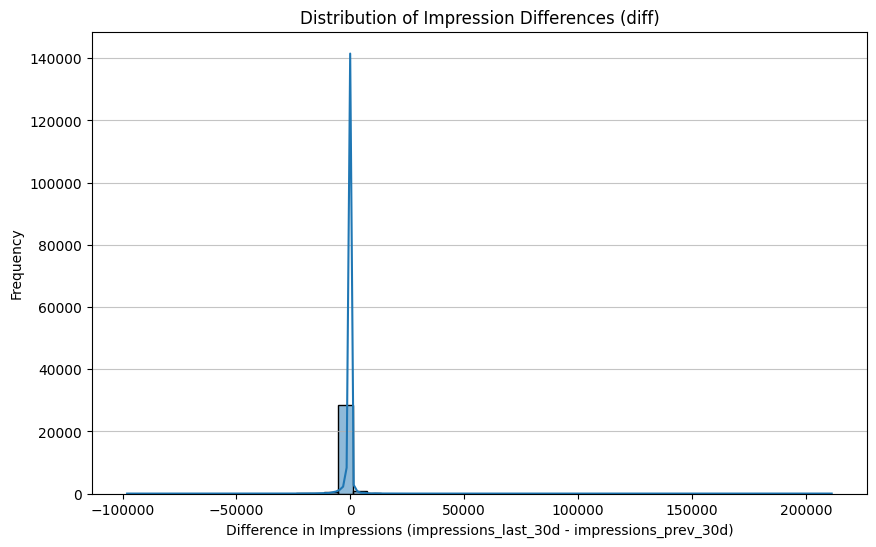

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(result['diff'], bins=50, kde=True)
plt.title('Distribution of Impression Differences (diff)')
plt.xlabel('Difference in Impressions (impressions_last_30d - impressions_prev_30d)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

In [19]:
#i can claim which pages have potential of boom and which pages experience largest boom or decline
#i cannot claim why a page booms or decline or by how much a page might boom.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.